# Load Packages

In [1]:
import pandas as pd
import numpy as np
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from dotenv import load_dotenv
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st

current_path = os.getcwd()
print(current_path)
new_path = '/Users/aminudidnaiman/spotify_analytics'
os.chdir(new_path)

print("Now in:",os.getcwd())
from utils.data_processing import (
    extract_top_artist_data,
    extract_top_tracks_data,
    get_albums_info,
    get_tracks_info
)

/Users/aminudidnaiman/spotify_analytics/test
Now in: /Users/aminudidnaiman/spotify_analytics


# Extract Spotify Credentials

In [2]:
env_path = Path("..") / ".env"
load_dotenv(dotenv_path=env_path)
CLIENT_ID = os.getenv("CLIENT_ID")
CLIENT_SECRET = os.getenv("CLIENT_SECRET")
REDIRECT_URI = os.getenv("REDIRECT_URI")

# Extract Spotify Data

## Fetch Top Tracks

In [3]:
# Optional: remove existing cache for fresh login
if os.path.exists(".cache-my-music-app"):
    os.remove(".cache-my-music-app")

# Create the OAuth object
sp_oauth = SpotifyOAuth(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    redirect_uri=REDIRECT_URI,
    scope=["user-top-read", "user-library-read", "playlist-read-private"],
    cache_path=".cache-my-music-app"
)

# Create the Spotify client using the SpotifyOAuth instance directly
sp = spotipy.Spotify(auth_manager=sp_oauth)

# Test API call
try:
    results = sp.current_user_top_tracks(limit=10)
    for idx, item in enumerate(results['items']):
        print(f"{idx+1}. {item['name']} - {item['artists'][0]['name']}")
except spotipy.exceptions.SpotifyException as e:
    print(f"Error: {e}")


print("Fetching your top tracks...")

short_term_track_data = extract_top_tracks_data(sp,'short_term')
medium_term_track_data = extract_top_tracks_data(sp,'medium_term')
long_term_track_data = extract_top_tracks_data(sp,'long_term')

1. CASANOVA POSSE - ALI
2. HER - MINNIE
3. Imaginary Friend - ITZY
4. Air - YEJI
5. I TRUST YOU - エミリア(CV:高橋李依)
6. Shopper - IU
7. Secret - IU
8. Whiplash - aespa
9. NEMONEMO - YENA
10. FREAK - YUQI
Fetching your top tracks...


## Fetch Top Artists

In [4]:
short_term_artists = extract_top_artist_data(sp,'short_term')
medium_term_artists = extract_top_artist_data(sp,'medium_term')
long_term_artists = extract_top_artist_data(sp,'long_term')

short_term_artists

,artist_name,popularity,genres,artist_id,followers,image_url
0,aespa,80,k-pop,6YVMFz59CuY7ngCxTxjpxE,8367687,https://i.scdn.co/image/ab6761610000e5ebf7a109...
1,YENA,56,k-pop,49muoiIu4uea4PO8vueUNN,808115,https://i.scdn.co/image/ab6761610000e5eb1135e1...
2,IU,71,"k-pop, k-ballad",3HqSLMAZ3g3d5poNaI7GOU,9137070,https://i.scdn.co/image/ab6761610000e5ebbd0642...
3,TAEYEON,67,"k-pop, k-ballad",3qNVuliS40BLgXGxhdBdqu,3065118,https://i.scdn.co/image/ab6761610000e5ebb5d9eb...
4,YUQI,60,k-pop,22aCD8IrQZjcPgZw728QT6,834279,https://i.scdn.co/image/ab6761610000e5eb569026...
5,MINNIE,63,k-pop,2pHkxVNynHBwQHhGaoBIXX,762958,https://i.scdn.co/image/ab6761610000e5eb1a9a17...
6,ITZY,69,k-pop,2KC9Qb60EaY0kW4eH68vr3,8353841,https://i.scdn.co/image/ab6761610000e5eb344806...
7,YEJI,61,k-pop,3skli1w2n0nOZ4qkDbvV2m,115696,https://i.scdn.co/image/ab6761610000e5eb485cfb...
8,TWICE,79,k-pop,7n2Ycct7Beij7Dj7meI4X0,21668870,https://i.scdn.co/image/ab6761610000e5ebca6c14...
9,NMIXX,71,k-pop,28ot3wh4oNmoFOdVajibBl,3608283,https://i.scdn.co/image/ab6761610000e5ebb75519...


## Extract additional information on Top Tracks

In [5]:
short_term_track_id  = short_term_track_data['track_id'].unique().tolist()
medium_term_track_id  = medium_term_track_data['track_id'].unique().tolist()
long_term_track_id  = long_term_track_data['track_id'].unique().tolist()

short_term_tracks = get_tracks_info(sp,short_term_track_id)
medium_term_tracks = get_tracks_info(sp,medium_term_track_id)
long_term_tracks = get_tracks_info(sp,long_term_track_id)

## Extract additional information on Albums

In [6]:
short_term_album_id  = short_term_track_data['album_id'].unique().tolist()
medium_term_album_id  = medium_term_track_data['album_id'].unique().tolist()
long_term_album_id  = long_term_track_data['album_id'].unique().tolist()

short_term_albums = get_albums_info(sp,short_term_album_id)
medium_term_albums = get_albums_info(sp,medium_term_album_id)
long_term_albums = get_albums_info(sp,long_term_album_id)

# Data Analysis

In [7]:
top_tracks_df = long_term_track_data
track_info_df = long_term_tracks
album_info_df = long_term_albums
artist_info_df = long_term_artists

In [8]:
duplicated_suffix = '_dup'
track_merged_df = top_tracks_df.merge(track_info_df,how = 'inner',on = ['track_id'],suffixes=('',duplicated_suffix))
track_merged_df = track_merged_df.loc[:,~track_merged_df.columns.str.endswith(duplicated_suffix)]
track_album_merged_df = track_merged_df.merge(album_info_df,how = 'left',on = ['album_id'],suffixes=('',duplicated_suffix))
track_album_merged_df = track_album_merged_df.loc[:,~track_album_merged_df.columns.str.endswith(duplicated_suffix)]
track_album_merged_df

,track_name,artist_name,album_name,album_id,release_date,popularity,duration_ms,explicit,track_id,duration_min,...,label,album_type,external_url,album_uri,release_date_precision,images,genres,artists,track_ids,available_markets
0,Nobody - from Kaiju No. 8,OneRepublic,Nobody (from Kaiju No. 8),3YmKf1haPAblZIrIPpuRTf,2024-04-12,70,153626,False,47N81NMkB488fuOwOC3Oip,2.560433,...,Mosley Music/Interscope Records,single,https://open.spotify.com/album/3YmKf1haPAblZIr...,spotify:album:3YmKf1haPAblZIrIPpuRTf,day,[https://i.scdn.co/image/ab67616d0000b2732b386...,,OneRepublic,[47N81NMkB488fuOwOC3Oip],"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C..."
1,I GOT YOU,TWICE,I GOT YOU,6RZHj6L3NqrvcKeiBHQbjL,2024-02-02,59,173240,False,35dhwUoJNlxrPyEIJkfDnx,2.887333,...,Republic Records - TWICE,single,https://open.spotify.com/album/6RZHj6L3NqrvcKe...,spotify:album:6RZHj6L3NqrvcKeiBHQbjL,day,[https://i.scdn.co/image/ab67616d0000b273d6a44...,,TWICE,"[35dhwUoJNlxrPyEIJkfDnx, 2iMtwujjXUGjpUraeSrvIm]","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C..."
2,FREAK,YUQI,YUQ1,7LYc8ngbhwha4aGJ5kVauc,2024-04-23,57,171080,False,6ERs9uORCo1MfV0m9ixCuv,2.851333,...,Cube Entertainment,album,https://open.spotify.com/album/7LYc8ngbhwha4aG...,spotify:album:7LYc8ngbhwha4aGJ5kVauc,day,[https://i.scdn.co/image/ab67616d0000b2736f99c...,,YUQI,"[6JgEbE6tFhcKILTL4Z82VA, 6kRV7e933KQw0BoXBkSoA...",[]
3,DIVE,TWICE,DIVE,0riep5s1F9ynpobjOSzbcr,2024-07-10,58,181860,False,5vK3WrTOp6rEoASx1jAsp1,3.031000,...,WM Japan,single,https://open.spotify.com/album/0riep5s1F9ynpob...,spotify:album:0riep5s1F9ynpobjOSzbcr,day,[https://i.scdn.co/image/ab67616d0000b27303661...,,TWICE,[5vK3WrTOp6rEoASx1jAsp1],"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C..."
4,Fate,(G)I-DLE,2,0mC9MXPddkzggVsOXh5gd3,2024-01-29,62,161546,False,2vNPGH1x5ZwxTjlvzLCyc2,2.692433,...,Cube Entertainment,album,https://open.spotify.com/album/0mC9MXPddkzggVs...,spotify:album:0mC9MXPddkzggVsOXh5gd3,day,[https://i.scdn.co/image/ab67616d0000b27342281...,,(G)I-DLE,"[0uLcuydgTo4ErT6aQQayuw, 3GwmjxMoBSFbcYVvZooKO...",[]
5,Doughnut,TWICE,Celebrate,1nqz3cEjuvCMo8RHLBI9kM,2022-07-27,53,263680,False,65rmgd5uMb4Rgqb5dSiU0p,4.394667,...,WM Japan,album,https://open.spotify.com/album/1nqz3cEjuvCMo8R...,spotify:album:1nqz3cEjuvCMo8RHLBI9kM,day,[https://i.scdn.co/image/ab67616d0000b27396f40...,,TWICE,"[4Y0chGCyYIRpdUqHJjndF7, 2Ij1NaPpsFSKJ0M65tSV4...","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C..."
6,MORE & MORE,TWICE,MORE & MORE,5KsduuDNWzt65TaHzmtciv,2020-06-01,63,199653,False,3omvXShuRPM3zbDpWYqf5g,3.327550,...,Republic Records - TWICE,album,https://open.spotify.com/album/5KsduuDNWzt65Ta...,spotify:album:5KsduuDNWzt65TaHzmtciv,day,[https://i.scdn.co/image/ab67616d0000b27324869...,,TWICE,"[3omvXShuRPM3zbDpWYqf5g, 128rj96Z6tTEU3h3awSMd...","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C..."
7,Red Rover,YUQI,YUQ1,7LYc8ngbhwha4aGJ5kVauc,2024-04-23,47,123320,False,4TQBHR8LcbBUv0LvLmn54H,2.055333,...,Cube Entertainment,album,https://open.spotify.com/album/7LYc8ngbhwha4aG...,spotify:album:7LYc8ngbhwha4aGJ5kVauc,day,[https://i.scdn.co/image/ab67616d0000b2736f99c...,,YUQI,"[6JgEbE6tFhcKILTL4Z82VA, 6kRV7e933KQw0BoXBkSoA...",[]
8,Full Moon Full Life,高橋あず美,Persona 3 Reload Original Soundtrack,20Bf2RVERC5Bc2eo3vyvJv,2024-04-24,65,293493,False,3Jl2LQmRwbXEF2lO1RTvxn,4.891550,...,ATLUS GAME MUSIC,album,https://open.spotify.com/album/20Bf2RVERC5Bc2e...,spotify:album:20Bf2RVERC5Bc2eo3vyvJv,day,[https://i.scdn.co/image/ab67616d0000b273e59bd...,,"アトラスサウンドチーム, ATLUS GAME MUSIC","[3Jl2LQmRwbXEF2lO1RTvxn, 1d5r3NM4fqH8po53LkMzB...","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C..."
9,YES or YES,TWICE,YES or YES,25VunQEW0x2W6ALND2Mh4g,2018-11-05,68,237680,False,26OVhEqFDQH0Ij77QtmGP9,3.961333,...,Republic Records - TWICE,album,https://open.spotify.com/album/25VunQEW0x2W6AL...,spotify:album:25VunQEW0x2W6ALND2Mh4g,day,[https://i.scdn.co/image/ab67616d0000b273140ba...,,TWICE,"[26OVhEqFDQH0Ij77QtmGP9, 7fEMfYZnjQ28Cpzi7QnkA...","[AR, AU, AT, BE, BO, BR, B

In [9]:
final_df = track_album_merged_df.merge(artist_info_df,how = 'left',on = ['artist_id'],suffixes=('',duplicated_suffix))
final_df = final_df.loc[:,~final_df.columns.str.endswith(duplicated_suffix)]
final_df

,track_name,artist_name,album_name,album_id,release_date,popularity,duration_ms,explicit,track_id,duration_min,...,external_url,album_uri,release_date_precision,images,genres,artists,track_ids,available_markets,followers,image_url
0,Nobody - from Kaiju No. 8,OneRepublic,Nobody (from Kaiju No. 8),3YmKf1haPAblZIrIPpuRTf,2024-04-12,70,153626,False,47N81NMkB488fuOwOC3Oip,2.560433,...,https://open.spotify.com/album/3YmKf1haPAblZIr...,spotify:album:3YmKf1haPAblZIrIPpuRTf,day,[https://i.scdn.co/image/ab67616d0000b2732b386...,,OneRepublic,[47N81NMkB488fuOwOC3Oip],"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",18140208.0,https://i.scdn.co/image/ab6761610000e5eb57138b...
1,I GOT YOU,TWICE,I GOT YOU,6RZHj6L3NqrvcKeiBHQbjL,2024-02-02,59,173240,False,35dhwUoJNlxrPyEIJkfDnx,2.887333,...,https://open.spotify.com/album/6RZHj6L3NqrvcKe...,spotify:album:6RZHj6L3NqrvcKeiBHQbjL,day,[https://i.scdn.co/image/ab67616d0000b273d6a44...,,TWICE,"[35dhwUoJNlxrPyEIJkfDnx, 2iMtwujjXUGjpUraeSrvIm]","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",21668870.0,https://i.scdn.co/image/ab6761610000e5ebca6c14...
2,FREAK,YUQI,YUQ1,7LYc8ngbhwha4aGJ5kVauc,2024-04-23,57,171080,False,6ERs9uORCo1MfV0m9ixCuv,2.851333,...,https://open.spotify.com/album/7LYc8ngbhwha4aG...,spotify:album:7LYc8ngbhwha4aGJ5kVauc,day,[https://i.scdn.co/image/ab67616d0000b2736f99c...,,YUQI,"[6JgEbE6tFhcKILTL4Z82VA, 6kRV7e933KQw0BoXBkSoA...",[],834279.0,https://i.scdn.co/image/ab6761610000e5eb569026...
3,DIVE,TWICE,DIVE,0riep5s1F9ynpobjOSzbcr,2024-07-10,58,181860,False,5vK3WrTOp6rEoASx1jAsp1,3.031000,...,https://open.spotify.com/album/0riep5s1F9ynpob...,spotify:album:0riep5s1F9ynpobjOSzbcr,day,[https://i.scdn.co/image/ab67616d0000b27303661...,,TWICE,[5vK3WrTOp6rEoASx1jAsp1],"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",21668870.0,https://i.scdn.co/image/ab6761610000e5ebca6c14...
4,Fate,(G)I-DLE,2,0mC9MXPddkzggVsOXh5gd3,2024-01-29,62,161546,False,2vNPGH1x5ZwxTjlvzLCyc2,2.692433,...,https://open.spotify.com/album/0mC9MXPddkzggVs...,spotify:album:0mC9MXPddkzggVsOXh5gd3,day,[https://i.scdn.co/image/ab67616d0000b27342281...,,(G)I-DLE,"[0uLcuydgTo4ErT6aQQayuw, 3GwmjxMoBSFbcYVvZooKO...",[],10492439.0,https://i.scdn.co/image/ab6761610000e5eb7fd163...
5,Doughnut,TWICE,Celebrate,1nqz3cEjuvCMo8RHLBI9kM,2022-07-27,53,263680,False,65rmgd5uMb4Rgqb5dSiU0p,4.394667,...,https://open.spotify.com/album/1nqz3cEjuvCMo8R...,spotify:album:1nqz3cEjuvCMo8RHLBI9kM,day,[https://i.scdn.co/image/ab67616d0000b27396f40...,,TWICE,"[4Y0chGCyYIRpdUqHJjndF7, 2Ij1NaPpsFSKJ0M65tSV4...","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",21668870.0,https://i.scdn.co/image/ab6761610000e5ebca6c14...
6,MORE & MORE,TWICE,MORE & MORE,5KsduuDNWzt65TaHzmtciv,2020-06-01,63,199653,False,3omvXShuRPM3zbDpWYqf5g,3.327550,...,https://open.spotify.com/album/5KsduuDNWzt65Ta...,spotify:album:5KsduuDNWzt65TaHzmtciv,day,[https://i.scdn.co/image/ab67616d0000b27324869...,,TWICE,"[3omvXShuRPM3zbDpWYqf5g, 128rj96Z6tTEU3h3awSMd...","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",21668870.0,https://i.scdn.co/image/ab6761610000e5ebca6c14...
7,Red Rover,YUQI,YUQ1,7LYc8ngbhwha4aGJ5kVauc,2024-04-23,47,123320,False,4TQBHR8LcbBUv0LvLmn54H,2.055333,...,https://open.spotify.com/album/7LYc8ngbhwha4aG...,spotify:album:7LYc8ngbhwha4aGJ5kVauc,day,[https://i.scdn.co/image/ab67616d0000b2736f99c...,,YUQI,"[6JgEbE6tFhcKILTL4Z82VA, 6kRV7e933KQw0BoXBkSoA...",[],834279.0,https://i.scdn.co/image/ab6761610000e5eb569026...
8,Full Moon Full Life,高橋あず美,Persona 3 Reload Original Soundtrack,20Bf2RVERC5Bc2eo3vyvJv,2024-04-24,65,293493,False,3Jl2LQmRwbXEF2lO1RTvxn,4.891550,...,https://open.spotify.com/album/20Bf2RVERC5Bc2e...,spotify:album:20Bf2RVERC5Bc2eo3vyvJv,day,[https://i.scdn.co/image/ab67616d0000b273e59bd...,,"アトラスサウンドチーム, ATLUS GAME MUSIC","[3Jl2LQmRwbXEF2lO1RTvxn, 1d5r3NM4fqH8po53LkMzB...","[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",NaN,NaN
9,YES or YES,TWICE,YES or YES,25VunQEW0x2W6ALND2Mh4g,2018-11-05,68,237680,False,26OVhEqFDQH0Ij77QtmGP9,3.96133

# Creating Dashboard

## Track Popularity

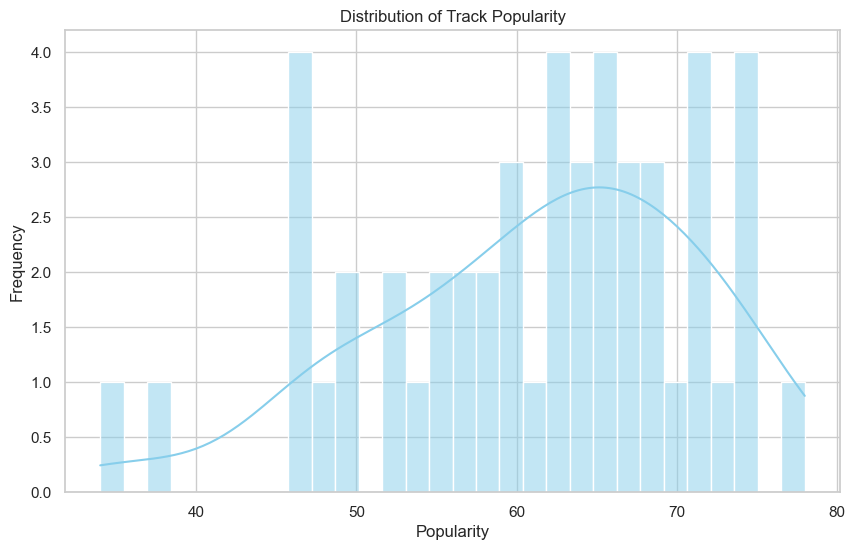

In [11]:
# Set style for Seaborn
sns.set(style="whitegrid")

# Track Popularity Distribution
plt.figure(figsize=(10, 6))
sns.histplot(final_df['popularity'], kde=True, color='skyblue', bins=30)
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

## Top Artists by Count

/var/folders/h2/_7ss5yb140n52wrlh1m9gwjr0000gn/T/ipykernel_19949/4084817719.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.index, y=top_artists.values, palette='Blues')


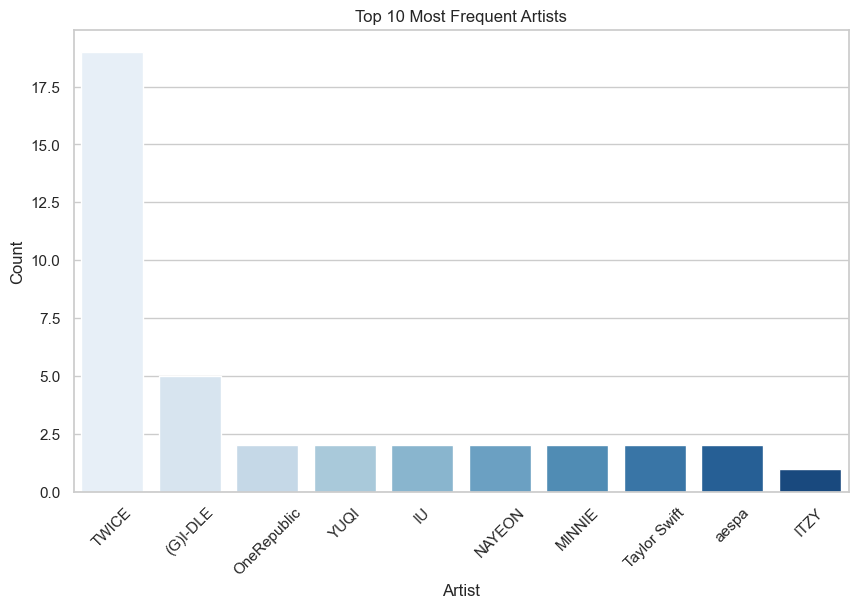

In [12]:
# Top Artists by Count
top_artists = final_df['artist_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists.index, y=top_artists.values, palette='Blues')
plt.title("Top 10 Most Frequent Artists")
plt.xlabel("Artist")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Top Albums

/var/folders/h2/_7ss5yb140n52wrlh1m9gwjr0000gn/T/ipykernel_19949/943403809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_albums.index, y=top_albums.values, palette='Blues')
/Users/aminudidnaiman/spotify_analytics/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19971 (\N{CJK UNIFIED IDEOGRAPH-4E03}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/aminudidnaiman/spotify_analytics/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/aminudidnaiman/spotify_analytics/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) Arial.
 

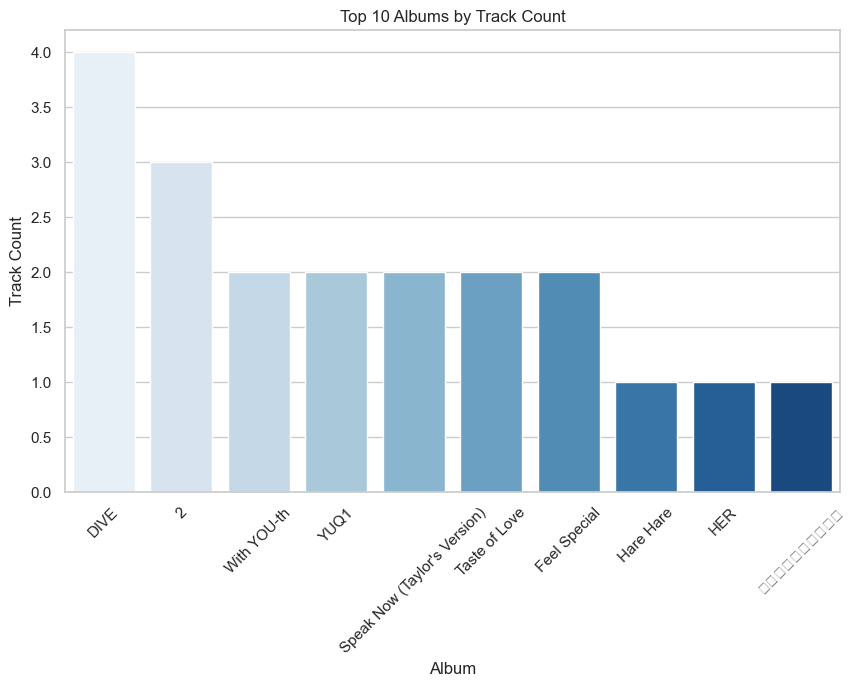

In [15]:
top_albums = final_df['album_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_albums.index, y=top_albums.values, palette='Blues')
plt.title("Top 10 Albums by Track Count")
plt.xlabel("Album")
plt.ylabel("Track Count")
plt.xticks(rotation=45)
plt.show()

## Explicit VS Non-Explicit

/var/folders/h2/_7ss5yb140n52wrlh1m9gwjr0000gn/T/ipykernel_19949/3368117475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='explicit', data=final_df, palette='Blues')


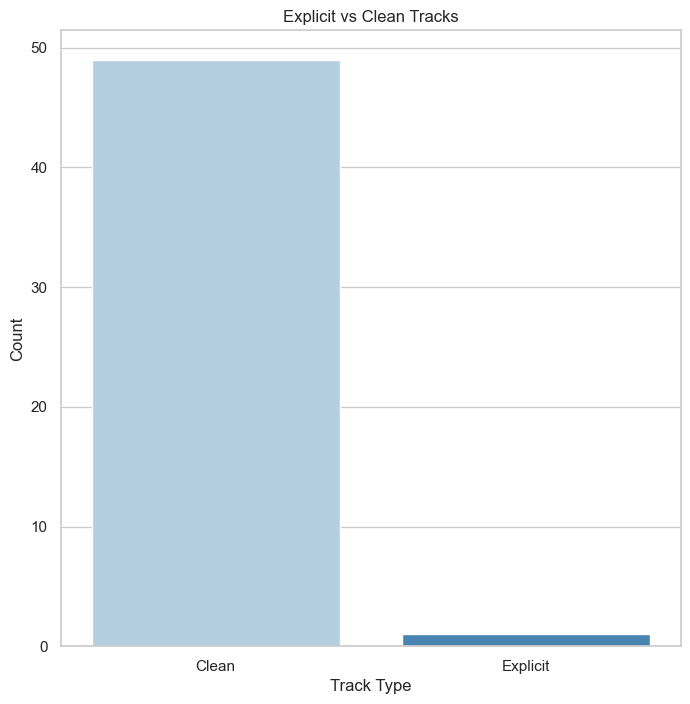

In [19]:
explicit_counts = final_df['explicit'].value_counts().rename({True: 'Explicit', False: 'Clean'})
plt.figure(figsize=(8, 8))
sns.countplot(x='explicit', data=final_df, palette='Blues')
plt.title("Explicit vs Clean Tracks")
plt.xlabel("Track Type")
plt.ylabel("Count")
plt.xticks([0, 1], ['Clean', 'Explicit'])
plt.show()

## Track Duration Distribution

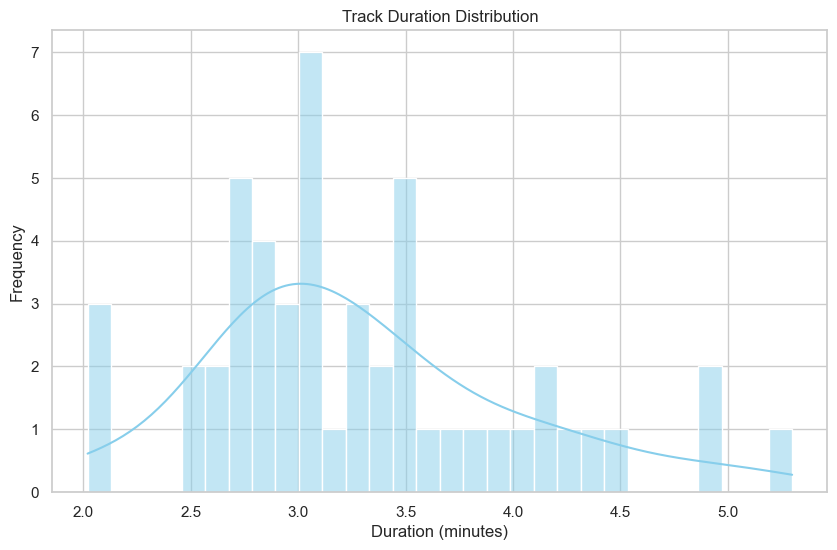

In [20]:
# Track Duration Distribution
plt.figure(figsize=(10, 6))
sns.histplot(final_df['duration_min'], kde=True, color='skyblue', bins=30)
plt.title("Track Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

## Release Year Trend

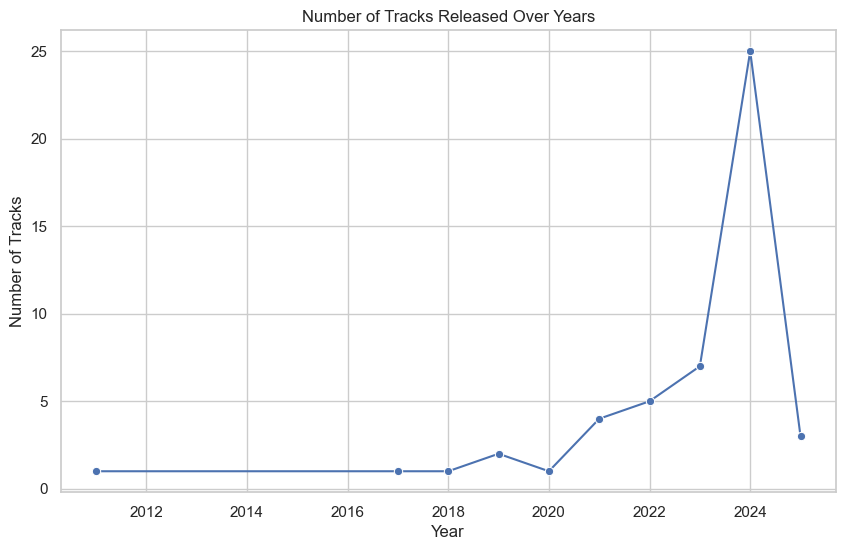

In [21]:
# Release Year Trend
final_df['release_year'] = final_df['release_date'].dt.year
yearly_counts = final_df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='b')
plt.title("Number of Tracks Released Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Tracks")
plt.show()

In [ ]:
from wordcloud import WordCloud
# Genre Distribution (if available)
if 'genres' in final_df.columns and final_df['genres'].notna().any():
    all_genres = ', '.join(final_df['genres'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_genres)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Genre Word Cloud")
    plt.show()